# 03. CRAG & Self-RAG: 자기 교정 검색 증강 생성

> CRAG는 **검색 결과**를, Self-RAG는 **생성 결과**를 검증해요. 두 자기 교정 RAG의 차이를 같은 데이터셋 위에서 비교해 봐요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **CRAG(Corrective RAG)** 패턴을 구현하여 문서 관련성을 평가하고 웹 검색으로 보강하는 RAG 시스템을 만들 수 있어요
2. **GradeDocuments** Pydantic 모델과 `with_structured_output()`으로 이진(yes/no) 문서 평가기를 구성할 수 있어요
3. **Query Rewriter**로 의미적 의도를 추출하여 벡터 검색 최적화 질문을 생성할 수 있어요
4. **Self-RAG** 패턴을 구현하여 문서 관련성 → 환각 검증 → 답변 관련성의 4단계 평가를 수행할 수 있어요
5. `GraphRecursionError`를 처리하여 무한 루프를 안전하게 방어할 수 있어요

## 사전 지식

- 이전 노트북 `02-Agentic-RAG.ipynb`에서 배운 Retriever, RAG Chain, GradeDocuments 패턴
- LangGraph의 StateGraph, 조건부 엣지, 노드 정의 방법
- Pydantic BaseModel과 `with_structured_output()` 기본 사용법

## Part 1: CRAG - Corrective RAG

**CRAG(Corrective-RAG)** 는 검색된 문서를 평가하고, 관련 없는 경우 쿼리를 재작성하여 웹 검색으로 보강하는 전략이에요.

### CRAG의 핵심 아이디어

전통적인 RAG는 검색 결과의 품질에 관계없이 그대로 사용해요. CRAG는 여기에 **자기 교정(Self-Correction)** 단계를 추가해요:

1. 문서를 검색하고 각 문서의 관련성을 평가해요
2. 관련 문서가 하나도 없으면 → 쿼리 재작성 → 웹 검색
3. 관련 문서가 있으면 → 그대로 답변 생성

> 🔑 **핵심 개념**: CRAG는 **논문 작성 과정**과 비슷해요. 참고문헌을 검색했는데 관련 없는 논문만 나왔다면, 검색어를 바꿔서 다른 데이터베이스(Google Scholar, arXiv)에서 다시 찾아보잖아요? CRAG가 정확히 이 과정을 자동화해요 — "검색이 실패했을 때 어떻게 할 것인가?"가 핵심이에요.

### 왜 이전 노트북의 Agentic RAG와 다른가요?

| 비교 항목 | 이전 Agentic RAG (02) | CRAG (이 노트북) |
|----------|----------------------|-----------------|
| 검색 실패 대응 | 쿼리 재작성 → 같은 소스 재검색 | 쿼리 재작성 → **다른 소스(웹)** 검색 |
| 문서 평가 | 전체 문서 일괄 평가 | **개별 문서 하나씩** 관련성 평가 |
| 필터링 | 있음 | 관련 없는 문서 제거 후 나머지만 사용 |
| 루프 구조 | 루프 가능 (무한 위험) | **1회 보완 후 진행** (루프 없음) |

### CRAG 아키텍처

```mermaid
flowchart TD
    A([START]) --> B[retrieve<br/>문서 검색]
    B --> C[grade_documents<br/>관련성 평가]
    C --> D{decide_to_generate<br/>평가 결과?}
    D -- "관련 문서 있음" --> G[generate<br/>답변 생성]
    D -- "관련 문서 없음" --> E[query_rewrite<br/>쿼리 재작성]
    E --> F[web_search_node<br/>웹 검색]
    F --> G
    G --> H([END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef terminal fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,H terminal
    class B,C,E,F process
    class D decision
    class G output
```

### CRAG의 핵심 구성 요소

| 구성 요소 | 역할 | 출력 |
|----------|------|------|
| `retrieve` | 벡터 검색으로 관련 문서 찾기 | 문서 리스트 |
| `grade_documents` | 각 문서의 관련성 평가 | 필터링된 문서 + web_search 플래그 |
| `query_rewrite` | 의미적 의도 추출, 검색 최적화 | 개선된 질문 |
| `web_search_node` | 타빌리(Tavily) 웹 검색 | 보강된 문서 |
| `generate` | 최종 답변 생성 | 답변 텍스트 |

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 설정
# ---------------------------------------------------
# dotenv: .env 파일에서 API 키를 읽어와요
from dotenv import load_dotenv

# API 키 정보 로드 (OPENAI_API_KEY, TAVILY_API_KEY 등)
load_dotenv(override=True)

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정
# ---------------------------------------------------
# LangSmith를 사용하면 그래프 실행 과정을 시각적으로 추적할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-RAG-CRAG-Self-RAG"

## 2. PDF 기반 Retriever 및 RAG Chain 구성

CRAG에서는 Retriever와 생성 체인을 분리해요. 이렇게 하면 각 노드에서 독립적으로 검색과 생성을 제어할 수 있어요.

> 💡 **실무 팁**: `PDFRetrievalChain` 같은 헬퍼 없이 직접 구성하면 내부 동작을 완전히 제어할 수 있어요. FAISS 인덱스, 청킹 전략, 임베딩 모델을 직접 선택할 수 있죠.

**실습 문서**: 소프트웨어정책연구소(SPRi) AI Brief 2023년 12월호  
파일명: `data/SPRI_AI_Brief_2023년12월호_F.pdf`

In [3]:
# ---------------------------------------------------
# PDF 로더, 임베딩, 벡터스토어 설정
# ---------------------------------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# PDF 파일 로드 (SPRI AI Brief 2023년 12월호)
PDF_PATH = "data/SPRI_AI_Brief_2023년12월호_F.pdf"

# 페이지 단위로 문서 로드
loader = PyPDFLoader(PDF_PATH)
pages = loader.load()
print(f"총 {len(pages)}페이지 로드 완료")

# 청크로 분할 (chunk_size: 한 청크의 최대 글자 수)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
)
docs = splitter.split_documents(pages)
print(f"총 {len(docs)}개 청크 생성")

# OpenAI 임베딩 + FAISS 벡터스토어 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(docs, embeddings)

# Retriever 생성 (유사도 기반, 상위 4개 문서 반환)
pdf_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
# Retriever 준비 완료

총 23페이지 로드 완료
총 85개 청크 생성


In [4]:
# ---------------------------------------------------
# RAG 체인 구성 (답변 생성용)
# ---------------------------------------------------
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 기본 모델: gpt-4o-mini (비용 효율)
# 다른 모델 옵션: "anthropic:claude-sonnet-4-5", "ollama:llama3"
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# RAG 프롬프트 템플릿 정의
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant. Answer the question based on the provided context.
If the context doesn't contain enough information, say so clearly.
Always cite your sources by mentioning the document name and page number."""),
    ("human", """Context: {context}

Question: {question}

Answer in Korean:""")
])


def format_docs(docs):
    """문서 리스트를 프롬프트 입력 형식으로 포맷팅해요."""
    return "\n\n".join(
        f"<document>\n<content>{doc.page_content}</content>\n"
        f"<source>{doc.metadata.get('source', 'unknown')}</source>\n"
        f"<page>{doc.metadata.get('page', 0) + 1}</page>\n</document>"
        for doc in docs
    )


# RAG 체인: 프롬프트 → LLM → 텍스트 파서
rag_chain = RAG_PROMPT | llm | StrOutputParser()
# RAG 체인 준비 완료

## 3. CRAG 핵심 컴포넌트 구성

### 3-1. 문서 관련성 평가기 (Retrieval Grader)

**GradeDocuments** 모델은 이진(yes/no) 점수로 각 문서의 관련성을 평가해요.

> 🔑 **핵심 개념**: `with_structured_output(GradeDocuments)`를 사용하면 LLM이 자유 텍스트 대신 정해진 구조로 응답해요. `binary_score`가 항상 `"yes"` 또는 `"no"`로만 나와요.

In [5]:
# ---------------------------------------------------
# 문서 관련성 평가기 (Retrieval Grader)
# ---------------------------------------------------
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


# Pydantic 모델: 이진 점수로 문서 관련성을 평가해요
class GradeDocuments(BaseModel):
    """검색된 문서의 관련성을 평가하는 이진 점수예요."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있으면 'yes', 없으면 'no'"
    )


# 구조화된 출력을 사용하는 LLM 생성
# with_structured_output: LLM이 GradeDocuments 형식으로만 응답하도록 강제해요
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 관련성 평가 프롬프트
grade_system = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", grade_system),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

# 관련성 평가기 체인 생성
retrieval_grader = grade_prompt | structured_llm_grader

# 테스트: 질문과 문서 관련성 확인
test_question = "삼성전자가 개발한 생성형 AI의 이름은?"
test_docs = pdf_retriever.invoke(test_question)

print(f"질문: {test_question}")
print(f"첫 번째 문서 관련성 평가: ", end="")
result = retrieval_grader.invoke({
    "question": test_question,
    "document": test_docs[0].page_content
})
print(result)

질문: 삼성전자가 개발한 생성형 AI의 이름은?
첫 번째 문서 관련성 평가: binary_score='yes'


### 3-2. 쿼리 재작성기 (Query Rewriter)

검색 결과가 부적절할 때, 원래 질문의 의미적 의도를 파악하여 더 나은 검색어로 변환해요.

> 💡 **실무 팁**: 쿼리 재작성은 벡터 검색 최적화에도 활용돼요. 사용자의 자연어 질문보다 핵심 키워드 중심의 질문이 임베딩 유사도 검색에서 더 좋은 결과를 가져오는 경우가 많아요.

In [6]:
# ---------------------------------------------------
# 쿼리 재작성기 (Query Rewriter)
# ---------------------------------------------------
# 용도: 의미적 의도를 추출하여 벡터 검색에 최적화된 질문으로 변환해요

rewrite_system = """You are a question re-writer that converts an input question to a better version 
that is optimized for web search. Look at the input and try to reason about the underlying 
semantic intent / meaning. Output only the improved question, no explanation."""

re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", rewrite_system),
    ("human", "Here is the initial question:\n\n{question}\n\nFormulate an improved question."),
])

# 질문 재작성기: 프롬프트 → LLM → 텍스트 파서
question_rewriter = re_write_prompt | llm | StrOutputParser()

# 테스트: 질문 재작성 확인
test_q = "삼성전자 AI"
rewritten = question_rewriter.invoke({"question": test_q})
print(f"원본: {test_q}")
print(f"재작성: {rewritten}")

원본: 삼성전자 AI
재작성: 삼성전자의 인공지능 기술은 어떤 것들이 있나요?


### 3-3. 웹 검색 도구

Tavily Search API를 사용하여 실시간 웹 검색을 수행해요. `TAVILY_API_KEY`가 `.env`에 설정되어 있어야 해요.

> ⚠️ **자주 하는 실수**: `TavilySearchResults`는 도구로 사용할 때와 직접 호출할 때 입력 형식이 달라요. 직접 호출 시에는 `{"query": "..."}`로 입력해요.

In [7]:
# ---------------------------------------------------
# 웹 검색 도구 (Tavily Search)
# ---------------------------------------------------
# TAVILY_API_KEY가 .env에 설정되어 있어야 해요
# 발급 주소: https://tavily.com
from langchain_tavily import TavilySearch

# 웹 검색 도구 생성 (최대 3개 결과 반환)
web_search_tool = TavilySearch(max_results=3)

# 테스트: 웹 검색 결과 확인
# 실제 API 호출이 이루어져요 (TAVILY_API_KEY 필요)
# TavilySearch.invoke()는 {"results": [...], ...} 딕셔너리를 반환해요
response = web_search_tool.invoke({"query": "삼성 가우스 생성형 AI"})
results = response.get("results", [])
print(f"웹 검색 결과 수: {len(results)}개")
if results:
    content = results[0].get('content', str(results[0]))
    print(f"첫 번째 결과 미리보기: {content[:100]}...")


웹 검색 결과 수: 3개
첫 번째 결과 미리보기: # 삼성 가우스. code.i Chat3.3.2. 그의 이름을 따른 삼성 생성형 AI 모델은 세상의 모든 현상과 지식을 담겠다는 의미를 가지고 있으며 텍스트, 코드, 이미지, 영상...


## 4. CRAG 그래프 구성

### 4-1. 상태(State) 정의

CRAG에서는 `web_search` 플래그를 상태에 포함하여 웹 검색 필요 여부를 노드 간에 전달해요.

In [8]:
# ---------------------------------------------------
# CRAG 상태(State) 정의
# ---------------------------------------------------
from typing import Annotated, List
from typing_extensions import TypedDict


class CRAGState(TypedDict):
    """CRAG 그래프의 상태 정의예요."""

    question: Annotated[str, "사용자 질문"]
    generation: Annotated[str, "생성된 답변"]
    web_search: Annotated[str, "웹 검색 필요 여부 ('Yes' 또는 'No')"]
    documents: Annotated[List, "검색된 문서 리스트"]

### 4-2. 노드 함수 정의

In [9]:
# ---------------------------------------------------
# CRAG 노드 함수 정의
# ---------------------------------------------------
from langchain_core.documents import Document


def retrieve(state: CRAGState) -> CRAGState:
    """문서를 검색하는 노드예요."""
    # ==== [RETRIEVE] ====
    question = state["question"]

    # 벡터 검색으로 관련 문서 찾기
    documents = pdf_retriever.invoke(question)
    return {"documents": documents}


def grade_documents(state: CRAGState) -> CRAGState:
    """검색된 문서의 관련성을 평가하는 노드예요.

    각 문서를 평가하여 관련 없는 문서를 필터링하고,
    관련 문서가 없으면 web_search 플래그를 'Yes'로 설정해요.
    """
    # ==== [GRADE DOCUMENTS] ====
    question = state["question"]
    documents = state["documents"]

    # 관련성 있는 문서만 필터링
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": d.page_content
        })
        if score.binary_score == "yes":
            #   ✓ 관련 문서
            filtered_docs.append(d)
        else:
            #   ✗ 관련 없는 문서 (필터링)
            pass

    # 관련 문서가 없으면 웹 검색 필요
    web_search = "Yes" if len(filtered_docs) == 0 else "No"
    return {"documents": filtered_docs, "web_search": web_search}


def query_rewrite(state: CRAGState) -> CRAGState:
    """쿼리를 재작성하는 노드예요.

    원본 질문의 의미적 의도를 추출하여
    웹 검색에 최적화된 질문으로 변환해요.
    """
    # ==== [QUERY REWRITE] ====
    question = state["question"]

    # 원본 질문 → 최적화된 질문
    better_question = question_rewriter.invoke({"question": question})
    print(f"  원본: {question}")
    print(f"  재작성: {better_question}")
    return {"question": better_question}


def web_search(state: CRAGState) -> CRAGState:
    """웹 검색을 수행하는 노드예요.

    Tavily API로 실시간 웹 검색을 수행하고
    결과를 Document 형식으로 변환하여 기존 문서에 추가해요.
    """
    # ==== [WEB SEARCH] ====
    question = state["question"]
    documents = state["documents"]

    # 웹 검색 수행
    # TavilySearch.invoke()는 {"results": [...], ...} 딕셔너리를 반환해요
    response = web_search_tool.invoke({"query": question})
    results = response.get("results", [])

    # 검색 결과를 Document 형식으로 합쳐서 추가
    web_content = "\n".join([r["content"] for r in results])
    web_doc = Document(
        page_content=web_content,
        metadata={"source": "web_search", "query": question}
    )
    documents.append(web_doc)
    print(f"  웹 검색 결과 추가 완료")
    return {"documents": documents}


def generate(state: CRAGState) -> CRAGState:
    """최종 답변을 생성하는 노드예요."""
    # ==== [GENERATE] ====
    question = state["question"]
    documents = state["documents"]

    # 문서가 Document 객체인 경우와 문자열인 경우를 모두 처리해요
    if documents and hasattr(documents[0], "page_content"):
        context = format_docs(documents)
    else:
        context = str(documents)

    # RAG 체인으로 답변 생성
    generation = rag_chain.invoke({"context": context, "question": question})
    return {"generation": generation}

### 4-3. 조건부 엣지 함수

In [10]:
# ---------------------------------------------------
# 조건부 엣지 함수
# ---------------------------------------------------


def decide_to_generate(state: CRAGState) -> str:
    """문서 평가 결과에 따라 다음 단계를 결정하는 라우팅 함수예요.

    Returns:
        'query_rewrite': 관련 문서가 없어 쿼리 재작성이 필요한 경우
        'generate': 관련 문서가 있어 바로 답변 생성 가능한 경우
    """
    # ==== [DECIDE TO GENERATE] ====
    web_search = state["web_search"]

    if web_search == "Yes":
        # 관련 문서가 없음 → 쿼리 재작성 후 웹 검색
        #   결정: 쿼리 재작성 (관련 문서 없음)
        return "query_rewrite"
    else:
        # 관련 문서 있음 → 바로 생성
        #   결정: 답변 생성 (관련 문서 있음)
        return "generate"

### 4-4. 그래프 조립 및 시각화

> 🎯 **강의 포인트**: 그래프 시각화를 보면서 CRAG의 두 경로를 설명해요:
> - **빠른 경로**: retrieve → grade → generate (관련 문서 있을 때)
> - **보완 경로**: retrieve → grade → rewrite → web_search → generate (관련 문서 없을 때)

In [11]:
# ---------------------------------------------------
# CRAG 그래프 조립
# ---------------------------------------------------
from langgraph.graph import END, StateGraph, START

# CRAGState 기반 그래프 초기화
crag_workflow = StateGraph(CRAGState)

# 노드 등록
crag_workflow.add_node("retrieve", retrieve)
crag_workflow.add_node("grade_documents", grade_documents)
crag_workflow.add_node("generate", generate)
crag_workflow.add_node("query_rewrite", query_rewrite)
crag_workflow.add_node("web_search_node", web_search)

# 엣지 연결
crag_workflow.add_edge(START, "retrieve")          # 시작 → 검색
crag_workflow.add_edge("retrieve", "grade_documents")  # 검색 → 평가

# 조건부 엣지: 평가 결과에 따라 분기
crag_workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite": "query_rewrite",  # 관련 문서 없음 → 재작성
        "generate": "generate",            # 관련 문서 있음 → 생성
    }
)

# 재작성 → 웹검색 → 생성 순서
crag_workflow.add_edge("query_rewrite", "web_search_node")
crag_workflow.add_edge("web_search_node", "generate")
crag_workflow.add_edge("generate", END)

# 그래프 컴파일 (체크포인터 없이 단순 실행)
crag_app = crag_workflow.compile()
# CRAG 그래프 컴파일 완료

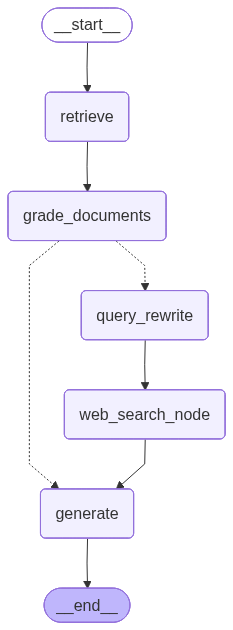

In [12]:
# ---------------------------------------------------
# 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → retrieve → grade_documents → (generate | query_rewrite → web_search_node → generate) → END
# retrieve: PDF 벡터 검색으로 관련 문서를 수집해요
# grade_documents: 각 문서의 관련성을 개별 평가하고 필터링해요
# decide_to_generate: 관련 문서가 있으면 generate, 없으면 query_rewrite로 분기해요
# query_rewrite: 의미적 의도를 추출하여 웹 검색 최적화 질문으로 변환해요
# web_search_node: Tavily로 웹 검색하여 보강 문서를 추가해요
# 두 경로(빠른/보완)가 어떻게 연결되는지 확인해요
from IPython.display import Image, display

display(Image(crag_app.get_graph().draw_mermaid_png()))

## 5. CRAG 실행 테스트

두 가지 경우를 테스트해요:
1. **PDF 내 정보** → 빠른 경로 (retrieve → grade → generate)
2. **PDF에 없는 정보** → 보완 경로 (rewrite → web_search → generate)

In [ ]:
# ---------------------------------------------------
# 테스트 1: PDF에 있는 정보 질문 (빠른 경로)
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

# config 설정: recursion_limit으로 무한 루프 방지
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# PDF에 존재하는 정보 질문
inputs = {"question": "삼성전자가 개발한 생성형 AI의 이름은?"}

# ============================================================
print(f"질문: {inputs['question']}")
# ============================================================

# 스트리밍 실행으로 각 노드의 처리 과정 확인
final_state = None
for chunk in crag_app.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "generation" in node_output:
            print(f"답변:\n{node_output['generation']}")
            final_state = node_output

질문: 삼성전자가 개발한 생성형 AI의 2026년 최신 근황을 알려줘

--- 노드: retrieve ---

--- 노드: grade_documents ---
  원본: 삼성전자가 개발한 생성형 AI의 2026년 최신 근황을 알려줘
  재작성: 삼성전자가 개발한 생성형 AI의 2026년 최신 동향은 무엇인가요?

--- 노드: query_rewrite ---
  웹 검색 결과 추가 완료

--- 노드: web_search_node ---

--- 노드: generate ---
답변:
제공된 문서에서는 삼성전자가 개발한 생성형 AI의 2026년 최신 동향에 대한 구체적인 정보는 포함되어 있지 않습니다. 대신, AI 에이전트 서비스와 관련된 내용이 주로 다루어지고 있으며, AI 에이전트가 기업 업무와 개발 환경을 어떻게 변화시키고 있는지에 대한 설명이 있습니다. AI 에이전트는 주변 환경을 인식하고, 스스로 행동을 계획하며 실행하는 지능형 소프트웨어 시스템으로, 기존의 생성형 AI와는 다른 방식으로 업무를 수행할 수 있는 능력을 가지고 있습니다. 

따라서, 삼성전자의 생성형 AI에 대한 구체적인 동향은 문서에서 확인할 수 없습니다. 추가적인 정보가 필요합니다. (출처: web_search, 페이지 1)


In [14]:
# ---------------------------------------------------
# 테스트 2: PDF에 없는 정보 질문 (보완 경로 - 웹 검색)
# ---------------------------------------------------
# 이 질문은 PDF에 없으므로 쿼리 재작성 → 웹 검색 경로를 탐
config2 = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs2 = {"question": "2024년 노벨 평화상 수상자는 누구인가요?"}

# ============================================================
print(f"질문: {inputs2['question']}")
# ============================================================

for chunk in crag_app.stream(inputs2, config2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "question" in node_output and node_name == "query_rewrite":
            print(f"재작성된 질문: {node_output['question']}")
        if "generation" in node_output:
            print(f"답변:\n{node_output['generation']}")

질문: 2024년 노벨 평화상 수상자는 누구인가요?

--- 노드: retrieve ---

--- 노드: grade_documents ---
  원본: 2024년 노벨 평화상 수상자는 누구인가요?
  재작성: 2024년 노벨 평화상 수상자는 누구인지 알고 싶습니다.

--- 노드: query_rewrite ---
재작성된 질문: 2024년 노벨 평화상 수상자는 누구인지 알고 싶습니다.
  웹 검색 결과 추가 완료

--- 노드: web_search_node ---

--- 노드: generate ---
답변:
2024년 노벨 평화상 수상자는 일본 원폭 생존자 단체인 '니혼 히단쿄'입니다. 이 단체는 핵무기 폐기를 위한 활동을 하고 있습니다. (출처: document, 페이지 1)


---

## Part 2: Self-RAG - 자기 반성 RAG

**Self-RAG**는 CRAG에서 한 단계 더 나아가, 생성된 답변 자체의 품질도 검증해요. "좋은 답변인가?"를 스스로 평가하고 아니면 다시 시도해요.

> 🔑 **핵심 개념**: CRAG가 **참고자료를 점검하는 사서**라면, Self-RAG는 **자기 답안을 교정하는 수험생**이에요. 시험 답안을 작성한 후 "이 답이 문제지에 있는 자료에 근거하고 있나?", "이 답이 실제로 문제를 해결하나?"를 스스로 되짚어보고, 아니면 다시 작성해요.

### 왜 CRAG만으로는 부족한가요?

CRAG는 **검색 단계**만 검증해요. 하지만 관련 문서를 찾았더라도 LLM이 **엉뚱한 답변**을 생성할 수 있어요:

| 상황 | CRAG의 한계 | Self-RAG의 해결 |
|------|-----------|----------------|
| 관련 문서는 찾았지만 LLM이 문서와 다른 내용을 생성 | 환각 감지 불가 | **Hallucination Grader**로 문서 근거 검증 |
| 관련 문서로 답변했지만 질문의 핵심을 빗나감 | 답변 품질 미검증 | **Answer Grader**로 질문 해결 여부 검증 |
| 웹 검색 없이 문서만 사용 | 문서에 없으면 포기 | 질문 재작성 → 재검색 루프 |

### Self-RAG vs CRAG 비교

| 기능 | CRAG | Self-RAG |
|------|------|----------|
| 문서 관련성 평가 | O | O |
| 쿼리 재작성 | O (웹검색 전) | O (문서 없을 때) |
| 웹 검색 보강 | O | X |
| 환각(Hallucination) 검증 | X | O |
| 답변 관련성 검증 | X | O |
| 자기 루프 | 1회 | 반복 가능 |

### Self-RAG의 4단계 평가

> 🎯 **강의 포인트**: Self-RAG는 논문([arXiv:2310.11511](https://arxiv.org/abs/2310.11511))에서 제안된 전략으로, 생성 단계에서 두 가지 질문을 추가로 물어요:
> 1. **환각 검증**: "이 답변이 검색된 문서에 근거하고 있나?"
> 2. **관련성 검증**: "이 답변이 실제로 질문에 답하고 있나?"

### Self-RAG 아키텍처

```mermaid
flowchart TD
    A([START]) --> B[retrieve<br/>문서 검색]
    B --> C[grade_documents<br/>문서 관련성 평가]
    C --> D{decide_to_generate}
    D -- "관련 문서 있음" --> E[generate<br/>답변 생성]
    D -- "관련 문서 없음" --> F[transform_query<br/>질문 재작성]
    F --> B
    E --> G{grade_generation<br/>생성 품질 평가}
    G -- "환각 감지" --> E
    G -- "질문 미해결" --> F
    G -- "좋은 답변" --> H([END])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef terminal fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef warning fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A,H terminal
    class B,C,E,F process
    class D,G decision
```

> ⚠️ **자주 하는 실수**: Self-RAG에서 루프가 반복되면 `GraphRecursionError`가 발생해요. 반드시 `recursion_limit`을 설정하고 에러를 처리해야 해요. CRAG와 달리 웹 검색 탈출구가 없으므로, 문서에 없는 정보를 질문하면 루프가 끝나지 않을 수 있어요.

## 6. Self-RAG 추가 평가기 구성

Self-RAG는 CRAG의 `retrieval_grader`에 더하여 두 개의 평가기를 더 사용해요.

In [15]:
# ---------------------------------------------------
# Self-RAG: 환각 평가기 (Hallucination Grader)
# ---------------------------------------------------
# 목적: 생성된 답변이 검색된 문서에 근거하는지 검증해요
# yes = 문서에 근거함 (환각 없음)
# no  = 문서와 무관한 내용 (환각 가능성)


class GradeHallucinations(BaseModel):
    """생성된 답변의 환각 여부를 평가하는 이진 점수예요."""

    binary_score: str = Field(
        description="답변이 문서에 근거하면 'yes', 아니면 'no'"
    )


# 환각 평가 전용 LLM (구조화 출력)
hallucination_grader_llm = llm.with_structured_output(GradeHallucinations)

hallucination_system = """You are a grader assessing whether an LLM generation is grounded in / 
supported by a set of retrieved facts.
Give a binary score 'yes' or 'no'. 
'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", hallucination_system),
    ("human", "Set of facts:\n\n{documents}\n\nLLM generation: {generation}"),
])

# 환각 평가기 체인
hallucination_grader = hallucination_prompt | hallucination_grader_llm

# 환각 평가기 준비 완료

In [16]:
# ---------------------------------------------------
# Self-RAG: 답변 관련성 평가기 (Answer Grader)
# ---------------------------------------------------
# 목적: 생성된 답변이 실제로 질문에 답하는지 검증해요
# yes = 질문을 해결함
# no  = 질문에 답하지 않음


class GradeAnswer(BaseModel):
    """답변이 질문을 해결하는지 평가하는 이진 점수예요."""

    binary_score: str = Field(
        description="답변이 질문을 해결하면 'yes', 아니면 'no'"
    )


# 답변 관련성 평가 전용 LLM
answer_grader_llm = llm.with_structured_output(GradeAnswer)

answer_system = """You are a grader assessing whether an answer addresses / resolves a question.
Give a binary score 'yes' or 'no'. 
'Yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_system),
    ("human", "User question:\n\n{question}\n\nLLM generation: {generation}"),
])

# 답변 관련성 평가기 체인
answer_grader = answer_prompt | answer_grader_llm

# 답변 관련성 평가기 준비 완료

In [17]:
# ---------------------------------------------------
# Self-RAG: 질문 재작성기
# ---------------------------------------------------
# CRAG의 query_rewriter와 유사하지만, 벡터스토어 검색에 최적화해요
# (CRAG는 웹 검색 최적화, Self-RAG는 벡터스토어 검색 최적화)

selfrag_rewrite_system = """You are a question re-writer that converts an input question to a better version 
that is optimized for vectorstore retrieval. 
Look at the input and try to reason about the underlying semantic intent / meaning.
Output only the improved question, no explanation."""

selfrag_rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", selfrag_rewrite_system),
    ("human", "Here is the initial question:\n\n{question}\n\nFormulate an improved question."),
])

# Self-RAG용 질문 재작성기
selfrag_question_rewriter = selfrag_rewrite_prompt | llm | StrOutputParser()
# Self-RAG 질문 재작성기 준비 완료

## 7. Self-RAG 그래프 구성

In [18]:
# ---------------------------------------------------
# Self-RAG 상태(State) 정의
# ---------------------------------------------------
# CRAG와 달리 web_search 플래그 없이 단순하게 구성해요

class SelfRAGState(TypedDict):
    """Self-RAG 그래프의 상태 정의예요."""

    question: Annotated[str, "사용자 질문"]
    generation: Annotated[str, "생성된 답변"]
    documents: Annotated[List, "검색된 문서 리스트"]

In [19]:
# ---------------------------------------------------
# Self-RAG 노드 함수 정의
# ---------------------------------------------------


def selfrag_retrieve(state: SelfRAGState) -> SelfRAGState:
    """문서 검색 노드예요."""
    # ==== [RETRIEVE] ====
    documents = pdf_retriever.invoke(state["question"])
    return {"documents": documents}


def selfrag_grade_documents(state: SelfRAGState) -> SelfRAGState:
    """문서 관련성 평가 노드예요.

    관련 없는 문서를 필터링해요.
    """
    # ==== [GRADE DOCUMENTS] ====
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": d.page_content
        })
        if score.binary_score == "yes":
            #   ✓ 관련 문서
            filtered_docs.append(d)
        else:
            #   ✗ 관련 없는 문서
            pass

    return {"documents": filtered_docs}


def selfrag_generate(state: SelfRAGState) -> SelfRAGState:
    """답변 생성 노드예요."""
    # ==== [GENERATE] ====
    question = state["question"]
    documents = state["documents"]

    context = format_docs(documents) if documents else "관련 문서를 찾을 수 없습니다."
    generation = rag_chain.invoke({"context": context, "question": question})
    return {"generation": generation}


def selfrag_transform_query(state: SelfRAGState) -> SelfRAGState:
    """질문 재작성 노드예요.

    문서가 없거나 답변 품질이 낮을 때 질문을 개선해요.
    """
    # ==== [TRANSFORM QUERY] ====
    question = state["question"]
    better_question = selfrag_question_rewriter.invoke({"question": question})
    print(f"  재작성: {better_question}")
    return {"question": better_question}

In [20]:
# ---------------------------------------------------
# Self-RAG 조건부 엣지 함수들
# ---------------------------------------------------


def selfrag_decide_to_generate(state: SelfRAGState) -> str:
    """문서 관련성에 따라 생성 또는 재작성으로 라우팅해요.

    Returns:
        'transform_query': 관련 문서가 없는 경우
        'generate': 관련 문서가 있는 경우
    """
    # ==== [DECIDE TO GENERATE] ====
    filtered_docs = state["documents"]

    if not filtered_docs:
        #   결정: 질문 재작성 (관련 문서 없음)
        return "transform_query"
    else:
        #   결정: 답변 생성
        return "generate"


def selfrag_grade_generation(state: SelfRAGState) -> str:
    """생성된 답변의 품질을 평가하는 핵심 조건부 엣지예요.

    두 단계로 평가해요:
    1. 환각 검증: 답변이 문서에 근거하는가?
    2. 관련성 검증: 답변이 질문을 해결하는가?

    Returns:
        'relevant'    : 좋은 답변 → END로 진행
        'not_relevant': 질문 미해결 → transform_query로 재시도
        'hallucination': 환각 감지 → 다시 generate
    """
    # ==== [GRADE GENERATION] ====
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    # 1단계: 환각 검증
    # 문서 텍스트로 변환 (평가기 입력용)
    docs_text = "\n".join([d.page_content for d in documents]) if documents else ""
    hallucination_score = hallucination_grader.invoke({
        "documents": docs_text,
        "generation": generation
    })

    if hallucination_score.binary_score == "yes":
        #   ✓ 환각 없음 (문서에 근거)

        # 2단계: 답변 관련성 검증
        answer_score = answer_grader.invoke({
            "question": question,
            "generation": generation
        })

        if answer_score.binary_score == "yes":
            #   ✓ 질문 해결됨 → 완료
            return "relevant"
        else:
            #   ✗ 질문 미해결 → 질문 재작성
            return "not_relevant"
    else:
        #   ✗ 환각 감지 → 재생성
        return "hallucination"

In [21]:
# ---------------------------------------------------
# Self-RAG 그래프 조립
# ---------------------------------------------------
from langgraph.checkpoint.memory import MemorySaver

# SelfRAGState 기반 그래프 초기화
selfrag_workflow = StateGraph(SelfRAGState)

# 노드 등록
selfrag_workflow.add_node("retrieve", selfrag_retrieve)
selfrag_workflow.add_node("grade_documents", selfrag_grade_documents)
selfrag_workflow.add_node("generate", selfrag_generate)
selfrag_workflow.add_node("transform_query", selfrag_transform_query)

# 엣지 연결
selfrag_workflow.add_edge(START, "retrieve")
selfrag_workflow.add_edge("retrieve", "grade_documents")

# 문서 평가 후 조건부 분기
selfrag_workflow.add_conditional_edges(
    "grade_documents",
    selfrag_decide_to_generate,
    {
        "transform_query": "transform_query",  # 관련 문서 없음 → 재작성
        "generate": "generate",                # 관련 문서 있음 → 생성
    }
)

# 생성 품질 평가 후 조건부 분기 (Self-RAG의 핵심 루프!)
selfrag_workflow.add_conditional_edges(
    "generate",
    selfrag_grade_generation,
    {
        "hallucination": "generate",       # 환각 → 다시 생성
        "relevant": END,                   # 좋은 답변 → 종료
        "not_relevant": "transform_query", # 질문 미해결 → 재작성
    }
)

# 재작성 후 다시 검색 (루프 구성)
selfrag_workflow.add_edge("transform_query", "retrieve")

# MemorySaver로 체크포인트 저장 (루프 상태 추적)
selfrag_app = selfrag_workflow.compile(checkpointer=MemorySaver())
# Self-RAG 그래프 컴파일 완료

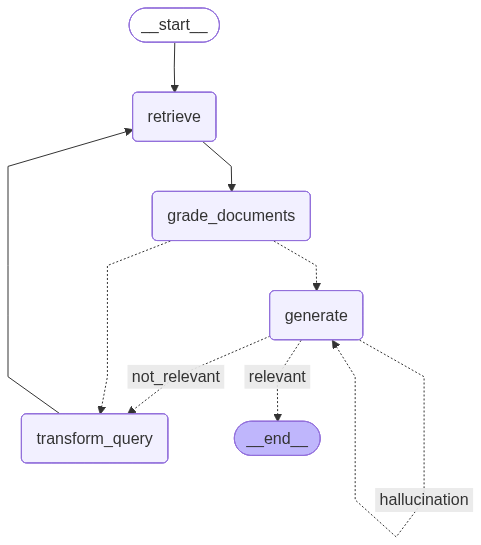

In [22]:
# ---------------------------------------------------
# Self-RAG 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → retrieve → grade_documents → (generate | transform_query) → grade_generation → (END | generate | transform_query)
# retrieve: PDF 벡터 검색으로 관련 문서를 수집해요
# grade_documents: 문서 관련성을 평가하여 generate 또는 transform_query로 분기해요
# generate: 답변을 생성해요
# grade_generation: 환각 검증 + 답변 관련성 검증의 2단계 품질 평가를 수행해요
# transform_query: 질문을 재작성하여 다시 retrieve로 루프해요
# 환각 감지 시 generate를 재실행, 질문 미해결 시 transform_query로 재시도해요
from IPython.display import Image, display
display(Image(selfrag_app.get_graph().draw_mermaid_png()))

## 8. Self-RAG 실행 테스트

> 🎯 **강의 포인트**: Self-RAG를 실행하면서 평가 결과에 따라 어떤 경로를 취하는지 로그를 보여주세요. 특히 환각 검증에서 `yes`가 나왔을 때와 아닐 때의 차이를 설명해요.

In [23]:
# ---------------------------------------------------
# Self-RAG 실행: PDF에 있는 정보 질문
# ---------------------------------------------------
selfrag_config = RunnableConfig(
    recursion_limit=10,  # Self-RAG는 루프가 있으므로 제한을 설정해요
    configurable={"thread_id": str(uuid.uuid4())}
)

selfrag_inputs = {"question": "삼성전자가 개발한 생성형 AI의 이름은?"}

# ============================================================
print(f"질문: {selfrag_inputs['question']}")
# ============================================================

# 스트리밍으로 각 노드 실행 과정 확인
final_answer = None
for chunk in selfrag_app.stream(selfrag_inputs, selfrag_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "generation" in node_output:
            final_answer = node_output["generation"]

if final_answer:
    # ============================================================
    # 최종 답변:
    print(final_answer)

질문: 삼성전자가 개발한 생성형 AI의 이름은?

--- 노드: retrieve ---

--- 노드: grade_documents ---

--- 노드: generate ---
삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'입니다. (출처: SPRI AI Brief, 2023년12월호, 페이지 13)


## 9. GraphRecursionError 처리

Self-RAG는 루프 구조를 갖고 있어서 문서에 없는 정보를 질문하면 무한 루프에 빠질 수 있어요. `GraphRecursionError`를 처리하여 안전하게 방어해요.

> ⚠️ **자주 하는 실수**: `recursion_limit`을 설정하지 않으면 기본값(25)까지 반복하다가 에러가 발생해요. 실제 서비스에서는 이 에러를 사용자 친화적인 메시지로 변환해야 해요.

In [24]:
# ---------------------------------------------------
# GraphRecursionError 처리 예시
# ---------------------------------------------------
# PDF에 없는 정보를 질문하면 루프에 빠져 RecursionError가 발생해요
from langgraph.errors import GraphRecursionError

recursion_config = RunnableConfig(
    recursion_limit=6,  # 낮은 값으로 설정하여 RecursionError를 빠르게 유발해요
    configurable={"thread_id": str(uuid.uuid4())}
)

# PDF에 없는 정보 질문 (가상의 인물은 이 PDF에 언급되지 않아요)
impossible_inputs = {"question": "홍길동이 개발한 생성형 AI의 이름은?"}

print(f"질문: {impossible_inputs['question']}")
# (PDF에 없는 정보 - 루프 발생 예상)
# ----------------------------------------

try:
    # 그래프 실행
    for chunk in selfrag_app.stream(
        impossible_inputs, recursion_config, stream_mode="updates"
    ):
        for node_name, _ in chunk.items():
            print(f"노드 실행: {node_name}")

except GraphRecursionError as e:
    # 실제 서비스에서는 사용자에게 안내 메시지를 반환해요
    print(f"\n[GraphRecursionError 처리]")
    # 재귀 한도에 도달했어요. 문서에서 관련 정보를 찾을 수 없습니다.
    print(f"(기술적 세부: {e})")

질문: 홍길동이 개발한 생성형 AI의 이름은?
노드 실행: retrieve
노드 실행: grade_documents
  재작성: 홍길동이 만든 생성형 AI의 이름은 무엇인가요?
노드 실행: transform_query
노드 실행: retrieve
노드 실행: grade_documents
  재작성: 홍길동이 개발한 생성형 AI의 이름은 무엇인가요?
노드 실행: transform_query

[GraphRecursionError 처리]
(기술적 세부: Recursion limit of 6 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT)


## 10. 실습: CRAG vs Self-RAG 비교

동일한 질문으로 두 방식을 비교해볼게요.

In [25]:
# ============================================================
# 실습 해설: CRAG와 Self-RAG 비교 실험
# ============================================================

comparison_questions = [
    "삼성전자가 공개한 생성 AI의 이름은 무엇인가요?",
    "이 문서에서 언급한 AI 반도체 시장 전망을 요약해줘",
]

for q in comparison_questions:
    print("\n" + "=" * 60)
    print("질문:", q)

    crag_config = RunnableConfig(
        recursion_limit=10,
        configurable={"thread_id": str(uuid.uuid4())},
    )
    crag_result = crag_app.invoke({"question": q}, crag_config)
    print(f"[CRAG 답변]\n{crag_result.get('generation', 'N/A')}")

    try:
        selfrag_config = RunnableConfig(
            recursion_limit=10,
            configurable={"thread_id": str(uuid.uuid4())},
        )
        selfrag_result = selfrag_app.invoke({"question": q}, selfrag_config)
        print(f"[Self-RAG 답변]\n{selfrag_result.get('generation', 'N/A')}")
    except GraphRecursionError:
        print("[Self-RAG] 루프 한도에 도달했어요. 질문 변환 또는 검색 조건을 조정해보세요.")



질문: 삼성전자가 공개한 생성 AI의 이름은 무엇인가요?
[CRAG 답변]
삼성전자가 공개한 생성 AI의 이름은 '삼성 가우스'입니다. (출처: SPRi AI Brief, 2023년12월호, 페이지 13)
[Self-RAG 답변]
삼성전자가 공개한 생성 AI의 이름은 '삼성 가우스'입니다. (출처: SPRi AI Brief, 2023년12월호, 페이지 13)

질문: 이 문서에서 언급한 AI 반도체 시장 전망을 요약해줘
  원본: 이 문서에서 언급한 AI 반도체 시장 전망을 요약해줘
  재작성: AI 반도체 시장 전망에 대한 요약은 무엇인가요?
  웹 검색 결과 추가 완료
[CRAG 답변]
AI 반도체 시장은 2023년 537억 달러에서 2028년 1,590억 달러로 성장할 것으로 예상되며, 연평균 24%의 성장률을 기록할 전망입니다. AI 반도체의 활용 분야는 데이터센터와 스마트폰에서 엣지디바이스로 확장될 것으로 보이며, 특히 PC용 엣지디바이스가 가장 높은 성장률인 62.8%를 기록할 것으로 예상됩니다. AI 가속기 시장도 2023년 793억 달러에서 2027년 2,029억 달러로 성장할 것으로 보이며, AI 반도체는 전체 반도체 시장의 약 20%를 차지할 것으로 전망됩니다. 이러한 성장세는 AI 반도체 기업의 주가에도 긍정적인 영향을 미치고 있으며, 엔비디아가 시장의 90% 이상을 차지하고 있습니다. 글로벌 빅테크 기업들도 AI 반도체 자체 생산에 막대한 투자를 하고 있습니다. (출처: 글로벌 AI 반도체 시장 현황 및 전망, 페이지 1)
  재작성: 이 문서에서 다룬 AI 반도체 시장 전망에 대한 요약은 무엇인가요?
  재작성: AI 반도체 시장 전망에 대한 이 문서의 주요 요약은 무엇인가요?
  재작성: AI 반도체 시장 전망에 대한 주요 요약은 무엇인가요?
[Self-RAG] 루프 한도에 도달했어요. 질문 변환 또는 검색 조건을 조정해보세요.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **CRAG(Corrective RAG)**: 문서 관련성 평가 후, 관련 없으면 쿼리 재작성 → 웹 검색으로 보강하는 전략이에요. `GradeDocuments` + `query_rewrite` + `web_search` 세 가지 컴포넌트가 핵심이에요.
- **GradeDocuments**: `Pydantic BaseModel` + `with_structured_output()`으로 LLM이 `binary_score: 'yes'/'no'`를 반환하도록 강제해요.
- **Self-RAG**: CRAG에 환각 검증(Hallucination Grader)과 답변 관련성 검증(Answer Grader)을 추가한 전략이에요. 생성 품질이 낮으면 재생성 또는 질문 재작성 루프를 실행해요.
- **Query Rewriter**: 원본 질문의 의미적 의도를 추출하여 검색에 최적화된 질문으로 변환해요.
- **GraphRecursionError**: `recursion_limit` + `try/except GraphRecursionError`로 무한 루프를 안전하게 방어해요.

### CRAG vs Self-RAG: 언제 어떤 것을 쓸까?

| 상황 | 추천 방식 | 이유 |
|------|----------|------|
| PDF + 웹 검색 모두 가능 | **CRAG** | 웹 검색 폴백으로 답변 범위가 넓어요 |
| 오프라인 환경 (웹 불가) | **Self-RAG** | 웹 검색 없이 자체 검증으로 품질 보장 |
| 답변 정확도가 매우 중요 | **Self-RAG** | 환각+관련성 이중 검증으로 높은 신뢰도 |
| 빠른 응답이 필요 | **CRAG** | 1회 보완으로 끝나서 더 빠름 |
| 가장 강력한 시스템 | **CRAG + Self-RAG 결합** | 다음 노트북의 Adaptive RAG가 이 조합이에요 |

> 💡 **실무 팁**: 실제 프로덕션에서는 CRAG와 Self-RAG를 결합하는 경우가 많아요. "검색 실패 → 웹 보완(CRAG)" + "생성 품질 검증(Self-RAG)"을 합치면 가장 견고한 RAG 시스템이 돼요. 다음 노트북의 **Adaptive RAG**가 바로 이 조합이에요.

## 다음 노트북 예고

다음 `04-Adaptive-RAG.ipynb`에서는 **Query Router와 3단계 조건부 라우팅**을 배워요. CRAG/Self-RAG는 항상 벡터스토어부터 검색하지만, Adaptive RAG는 **질문을 먼저 분류해서 vectorstore / web_search 중 최적 경로를 선택**해요. "2024년 노벨상 수상자" 같은 최신 질문은 처음부터 웹으로, "논문 내용"은 처음부터 벡터스토어로 보내서 시간과 비용을 아끼는 전략이에요.